In [ ]:
# Hosted D2L setup: fetch the exact helper module used to build this notebook.
from pathlib import Path
from urllib.request import urlretrieve
from importlib.metadata import PackageNotFoundError, version
import importlib.util, os, subprocess, sys

required = ['numpy', 'pandas', 'matplotlib', 'requests', 'scipy', 'pillow', 'regex', 'jax', 'jaxlib', 'flax', 'optax', 'orbax-checkpoint', 'tensorflow', 'protobuf', 'ml-dtypes']
imports = {'pillow': 'PIL', 'orbax-checkpoint': 'orbax', 'protobuf': 'google.protobuf', 'ml-dtypes': 'ml_dtypes'}
pinned = {'jax': ('0.10.2', 'jax==0.10.2', 'jax[cuda12]==0.10.2', 'exact'), 'jaxlib': ('0.10.2', 'jaxlib==0.10.2', 'jaxlib==0.10.2', 'exact'), 'flax': ('0.12.7', 'flax==0.12.7', 'flax==0.12.7', 'exact'), 'optax': ('0.2.8', 'optax==0.2.8', 'optax==0.2.8', 'exact'), 'orbax-checkpoint': ('0.12.0', 'orbax-checkpoint==0.12.0', 'orbax-checkpoint==0.12.0', 'exact')}
fallbacks = {'tensorflow': 'tensorflow==2.21.0', 'protobuf': 'protobuf==7.34.1', 'ml-dtypes': 'ml-dtypes==0.5.4'}
device = os.environ.get("D2L_HOSTED_DEVICE", "auto").lower()
if device not in ("auto", "cpu", "gpu"):
    raise ValueError(f"Invalid D2L_HOSTED_DEVICE={device!r}")
if device == "auto":
    try:
        gpu = (Path("/dev/nvidia0").exists() or
               subprocess.run(["nvidia-smi", "-L"], capture_output=True,
                              timeout=5).returncode == 0)
    except (FileNotFoundError, subprocess.SubprocessError):
        gpu = False
else:
    gpu = device == "gpu"
if not gpu:
    os.environ.setdefault("CUDA_VISIBLE_DEVICES", "-1")
    os.environ.setdefault("JAX_PLATFORMS", "cpu")
tensorflow_version = None
if 'jax' in ("tensorflow", "jax"):
    try:
        tensorflow_version = version("tensorflow")
    except PackageNotFoundError:
        pass
# Colab's CPU image currently carries a CUDA-enabled TensorFlow wheel. Its
# first ordinary tensor operation probes CUDA and emits an error-level cuInit
# diagnostic. JAX notebooks also use TensorFlow for data loading, so overlay
# the matching CPU build in both CPU variants. Keep the provider's
# ``tensorflow`` distribution metadata: other preinstalled Colab packages
# depend on that distribution name, while both wheels expose the same module.
if not gpu and 'jax' in ("tensorflow", "jax"):
    try:
        tensorflow_cpu_version = version("tensorflow-cpu")
    except PackageNotFoundError:
        tensorflow_cpu_version = None
    if (tensorflow_version is not None and
            tensorflow_cpu_version != tensorflow_version):
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", "--no-deps",
            f"tensorflow-cpu=={tensorflow_version}",
        ])
if "tf-keras" in fallbacks and tensorflow_version is not None:
    fallbacks["tf-keras"] = f"tf-keras=={tensorflow_version}"
missing = []
for package in required:
    if package in pinned:
        wanted, cpu_requirement, gpu_requirement, match = pinned[package]
        requirement = gpu_requirement if gpu else cpu_requirement
        try:
            installed = version(package)
        except PackageNotFoundError:
            installed = None
        actual = (installed.split("+", 1)[0]
                  if installed is not None and match == "public" else installed)
        if actual != wanted:
            missing.append(requirement)
    elif importlib.util.find_spec(imports.get(package, package)) is None:
        missing.append(fallbacks.get(package, package))
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

mismatched = []
for package, (wanted, _, _, match) in pinned.items():
    try:
        installed = version(package)
    except PackageNotFoundError:
        installed = None
    actual = (installed.split("+", 1)[0]
              if installed is not None and match == "public" else installed)
    if actual != wanted:
        mismatched.append(f"{package}={installed!r} (expected {wanted})")
if mismatched:
    raise RuntimeError("Hosted runtime setup failed: " + ", ".join(mismatched))

root = Path(".d2l-hosted") / "8cd319b4f2187b6b29bb69603a96460fc325a975"
package = root / "d2l"
package.mkdir(parents=True, exist_ok=True)
base = "https://raw.githubusercontent.com/smolix/d2l-neu/8cd319b4f2187b6b29bb69603a96460fc325a975/d2l"
for name in ('__init__.py', 'jax.py'):
    target = package / name
    if not target.exists():
        urlretrieve(f"{base}/{name}", target)
if str(root.resolve()) not in sys.path:
    sys.path.insert(0, str(root.resolve()))
pythonpath = os.environ.get("PYTHONPATH", "").split(os.pathsep)
if str(root.resolve()) not in pythonpath:
    os.environ["PYTHONPATH"] = os.pathsep.join(
        [str(root.resolve()), *[entry for entry in pythonpath if entry]]
    )


# Naive Bayes

The maximum-likelihood principle of that section tells us how to *fit* a probabilistic model, and the statistics of that section tell us how to *judge* one; here both go to work on a classifier. The **naive Bayes** classifier is among the simplest models that deserve the name "learning": it estimates a probability model by counting, predicts with Bayes' rule, and survives the curse of dimensionality through one visibly wrong assumption. We build it end to end, run it on handwritten digits, and then examine the result with the tools this chapter built: a bootstrap error bar on its accuracy, a look at which digits it actually confuses, and a measurement of how far its confidence can be trusted.

In [1]:
%matplotlib inline
from d2l import jax as d2l
import numpy as np
import tensorflow as tf
d2l.use_svg_display()

## Bayes' Rule for Classification

A classifier maps an example $\mathbf{x}\in\mathbb{R}^d$ to a label $y\in\{1,\ldots,K\}$. The natural target is the *posterior* $p(y\mid\mathbf{x})$, how plausible each label is given what we observed, and the natural prediction is its most likely value,

$$\hat{y} = \mathop{\mathrm{argmax}}_y \, p(y\mid\mathbf{x}).$$

Estimating $p(y\mid\mathbf{x})$ directly is hopeless. With $d$ binary features there are $2^d$ distinct inputs $\mathbf{x}$; storing a label distribution for each would need on the order of $2^d$ numbers, and we would have to *see* most of those inputs to estimate them. With the $784$ pixels of an MNIST image that is $2^{784}$ patterns, vastly more than there are atoms in the universe. Memorizing one answer per input amounts to a lookup table we could never fill.

Bayes' rule, the equation, turns the problem around. Instead of modelling "which label, given this image," we model "which images, given this label", the *generative* direction:

$$\hat{y} = \mathop{\mathrm{argmax}}_y \, p(y\mid\mathbf{x}) = \mathop{\mathrm{argmax}}_y \, \frac{p(\mathbf{x}\mid y)\,p(y)}{p(\mathbf{x})} = \mathop{\mathrm{argmax}}_y \, p(\mathbf{x}\mid y)\,p(y).$$

The denominator $p(\mathbf{x})$ is the same for every $y$, so it cannot change which label wins the $\mathrm{argmax}$ and we drop it; in shorthand, $p(y\mid\mathbf{x}) \propto p(\mathbf{x}\mid y)\,p(y)$. (Should we ever want the actual posterior probabilities, normalizing the numerators so they sum to one recovers $p(\mathbf{x})$ for free.)

This is the defining choice of a **generative** classifier: rather than modelling the label given the data, it models how the *data are generated* within each class, $p(\mathbf{x}\mid y)$, together with how often each class occurs, $p(y)$, and lets Bayes' rule turn that into a decision. It is the opposite of the **discriminative** route taken by logistic regression and the softmax classifier of that section, which fit the posterior $p(y\mid\mathbf{x})$ directly, without requiring a model for the marginal input distribution. The two form the classic generative--discriminative pair. In particular
well-specified comparisons, including the models analyzed by
@Ng.Jordan.2002, a generative model can approach its asymptotic error
with fewer examples while a discriminative model reaches a lower asymptotic
error. This is a model-dependent trade-off, not a universal law: either side can
win when its assumptions better match the data. Naive Bayes is the simplest generative classifier in wide use. the figure sketches the two routes side by side.

![Two routes to a classifier. Left: a generative model learns how each class generates inputs (the class-conditional densities $p(\mathbf{x}\mid y)$ weighted by the priors $p(y)$) and flips them through Bayes' rule, predicting whichever class makes the observation most plausible; the tie point of the weighted densities is where the decision flips. Right: a discriminative model need not specify how inputs are generated; it devotes its capacity directly to the posterior $p(y\mid\mathbf{x})$, that is, to the decision boundary between the classes.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-prob-naive-genvdisc.svg)

The reframing has not yet helped computationally: the *class-conditional* $p(\mathbf{x}\mid y)$ is still a distribution over the same $2^d$ patterns. The chain rule of probability (that section) lays the difficulty bare,

$$p(\mathbf{x}\mid y) = p(x_1\mid y)\,p(x_2\mid x_1, y)\cdots p(x_d\mid x_1,\ldots,x_{d-1}, y),$$

a product whose later factors condition on ever-longer histories and still hide $2^d$ parameters.

### The Naive Assumption

Here is the leap. *Assume the features are jointly conditionally independent
given the label.* Pairwise conditional independence alone is not enough when
$d>2$; the naive Bayes assumption is the full factorization of the conditional
joint distribution into one-feature marginals:

$$p(\mathbf{x}\mid y) = \prod_{i=1}^d p(x_i\mid y).$$

As a graphical model the assumption is a star: the label $y$ points to every
feature, and the features are joined by nothing
(the figure, left). All a feature can learn about the
others, it learns through the class label; given $y$, the features no longer
talk to one another. A faithful model of a digit would add edges *among* the
features (neighboring pixels co-fire), and naive Bayes simply erases them
(the figure, right).

![The naive assumption as a graphical model. Left: the label $y$ fans out to the features $x_1,\ldots,x_d$ with no edges *among* the features, so they are independent once $y$ is known: the picture of conditional independence. Right: a faithful model would carry dependence edges between features (here $x_1$–$x_2$ and $x_3$–$x_d$); naive Bayes throws them away (struck out), which is exactly what makes it cheap and what makes it wrong.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-prob-naive-independence.svg)

This is the assumption that makes Bayes "naive," and it is *false*: in a real digit the pixels are strongly correlated, since an inked pixel makes its neighbors far more likely to be inked too. The model pretends each pixel is painted by an independent coin flip whose bias depends only on the digit. Yet the assumption is cheap. We no longer estimate one giant joint distribution; we estimate $d$ tiny one-feature distributions $p(x_i\mid y)$ per class, only $\mathcal{O}(dK)$ numbers instead of $\mathcal{O}(2^d K)$. The curse of dimensionality, the same exponential blow-up that defeats grid-based integration in that section, is broken by fiat.

Why tolerate a false assumption? Because the classifier only needs the largest probability to land on the correct label; the probabilities themselves can be far off. A model can be badly miscalibrated (massively over- or under-confident, as multiplying $784$ falsely-independent factors will be) and still pick the right winner. Naive Bayes routinely classifies well even where its independence story is plainly wrong [@Domingos.Pazzani.1997], and the savings let it learn from a modest dataset rather than an impossible one.

Substituting the factorized class-conditional the equation into the Bayes-rule predictor $\hat{y} = \mathop{\mathrm{argmax}}_y p(\mathbf{x}\mid y)\,p(y)$ (the label-independent denominator already discarded) gives the **naive Bayes classifier** [@Maron.1961]:

$$\hat{y} = \mathop{\mathrm{argmax}}_y \; p(y) \prod_{i=1}^d p(x_i\mid y).$$

### Doing It in Log Space

Equation the equation multiplies $d$ probabilities, each in $[0,1]$. For $d=784$ the product is vanishingly small: on the MNIST model below, single precision underflows $99.1\%$ of all class scores to an exact zero (the prediction cell measures this directly), leaving the $\mathrm{argmax}$ to break ties among zeros; even in double precision the surviving products run from about $10^{-26}$ down to $10^{-323}$, the very bottom of the representable range charted in that section. This is the practical face of the numerical issue we met in that section, and the fix is the same: the $\mathrm{argmax}$ is unchanged by the increasing map $\log$, and $\log$ turns the product into a sum. Applied to the equation this gives the log-space form

$$\hat{y} = \mathop{\mathrm{argmax}}_y \; \log p(y) + \sum_{i=1}^d \log p(x_i\mid y).$$

A score is now a sum of $785$ well-behaved logarithms instead of a product that rounds to zero; the classifier becomes one table of pre-computed log-probabilities and a few additions.

The score also has a telling shape. For a binary feature, $\log p(x_i\mid y) = x_i \log p(x_i{=}1\mid y) + (1-x_i)\log p(x_i{=}0\mid y)$, so the log-space objective the equation becomes

$$\log p(y) + \sum_{i=1}^d \Bigl[ x_i \log p(x_i{=}1\mid y) + (1-x_i)\log p(x_i{=}0\mid y) \Bigr],$$

which is **affine in $\mathbf{x}$**, a constant plus a weighted sum of the pixels [@Bishop.2006]. Each class score is therefore $\mathbf{w}_y\cdot\mathbf{x} + b_y$, and the boundary between any two classes, where their scores tie, is a hyperplane. So naive Bayes is a *linear* classifier: it carves the input space with the same decision planes as the softmax classifier of that section (and the mean-difference rule of that section); the two models differ only in how they *set* those planes: by counting class-conditional frequencies here, by gradient descent on the posterior there.

## Training Is Counting

Naive Bayes needs two ingredients: the class prior $p(y)$ and, for each class, the per-feature likelihoods $p(x_i\mid y)$. Both are estimated by **maximum likelihood**, and for the categorical and Bernoulli models here the MLE is just an empirical frequency: *training is counting*.

For the prior, the maximum-likelihood estimate of $p(y)$ is the fraction of training examples carrying label $y$: if class $y$ appears $n_y$ times in $n = \sum_y n_y$ examples, then $\hat p(y) = n_y / n$. For binary features, $p(x_i = 1\mid y)$ is the probability that feature $i$ fires for class $y$, a Bernoulli parameter whose MLE is again a frequency: of the $n_y$ examples in class $y$, the fraction in which feature $i$ is on. Storing the values $\hat p(x_i = 1 \mid y)$ in an array $P_{xy}$ (in the code below, one $28\times 28$ grid per class) fixes both Bernoulli outcomes, since $\hat p(x_i = 0\mid y) = 1 - \hat p(x_i = 1\mid y)$.

One hazard remains. If feature $i$ is *never* on for class $y$ in the training set, the MLE is $\hat p(x_i=1\mid y)=0$, and a single such feature at test time annihilates the whole product in the equation (and sends the equation to $-\infty$). The cure is **Laplace smoothing** [@Laplace.1814]: add a pseudocount, estimating $p(x_i=1\mid y)$ as $(n_{iy}+1)/(n_y+2)$ rather than $n_{iy}/n_y$, where $n_{iy}$ counts the class-$y$ examples with feature $i$ on and the $+2$ covers the two outcomes a binary pixel can take; a categorical feature with $v$ possible values gets $+1$ on each value's count and $+v$ in the denominator, so the smoothed probabilities still sum to one (the text models at the end of this section smooth the same way, with $+|V|$ for a vocabulary $V$). The pseudocount has a Bayesian justification: $(n_{iy}+1)/(n_y+2)$ is the posterior *mean* of the Bernoulli parameter under a uniform $\mathrm{Beta}(1,1)$ prior, Laplace's *rule of succession*, as that section derives (along with the numerically coincident, but conceptually distinct, $\mathrm{Beta}(2,2)$ MAP estimate it is often conflated with).

Nothing in the recipe is married to binary features, either. For continuous inputs the standard move is **Gaussian naive Bayes**: model each feature, within each class, by a univariate Gaussian (that section), so that training is again a single counting-style pass (a per-class, per-feature mean and variance) and the log-space score the equation simply sums Gaussian log-densities instead of Bernoulli ones. That is the principled alternative to *thresholding* continuous features into bits, which is what we do to the pixel intensities below; thresholding gives an even simpler model but discards the gray levels.

## A Worked Example: MNIST Digits

We classify handwritten digits from MNIST [@LeCun.Bottou.Bengio.ea.1998]: $28\times 28$ grayscale images of the digits $0$ through $9$. To make each pixel a binary feature we threshold it at half-intensity, so $x_i\in\{0,1\}$ records whether pixel $i$ is inked. We load the two splits and binarize, ending with plain NumPy arrays: `X` of shape `(n, 28, 28)` and integer labels `Y`. Only this loading step touches the deep learning library; everything from here on is plain NumPy counting.

In [2]:
(X, Y), (X_test, Y_test) = tf.keras.datasets.mnist.load_data()
X = np.floor(X / 128).astype('float32')
X_test = np.floor(X_test / 128).astype('float32')
X.shape, Y.shape

((60000, 28, 28), (60000,))

### Estimating the Model

Training is two counts, done in NumPy. The prior $\hat p(y)$ is the class frequency; the likelihood array $P_{xy}$ holds, for each class, the Laplace-smoothed fraction of its images in which each pixel is inked. Prediction will then work in log space. The per-class `for y in range(10)` loop below is written for clarity, one class at a time; an idiomatic vectorized form would replace it with `np.bincount(Y)` for the class counts and a one-hot matrix multiply `onehot(Y).T @ X` for the per-class pixel sums.

In [3]:
n_y = np.array([(Y == y).sum() for y in range(10)])
P_y = n_y / n_y.sum()                                  # class prior, p(y)

n_x = np.stack([X[Y == y].sum(axis=0) for y in range(10)])
P_xy = (n_x + 1) / (n_y + 2).reshape(10, 1, 1)         # Laplace-smoothed p(x_i=1|y)
P_y

array([0.09871667, 0.11236667, 0.0993    , 0.10218333, 0.09736667,
       0.09035   , 0.09863333, 0.10441667, 0.09751667, 0.09915   ])

Each class's slice of $P_{xy}$ is a $28\times 28$ image of per-pixel "on" probabilities for one digit: a picture of what the model believes a class looks like. Plotting all ten shows ghostly averaged digits: this is the entire learned model.

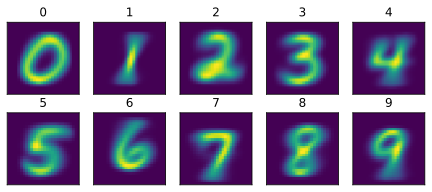

In [4]:
d2l.show_images([P_xy[y] for y in range(10)], 2, 5,
                titles=[str(y) for y in range(10)]);

The blur is the naive assumption made visible: the model knows each pixel's marginal firing rate but nothing about how pixels co-occur, so every sharp stroke smears into an average.

### Classifying and Evaluating

Prediction sums log-likelihoods per the equation. We precompute $\log P_{xy}$, $\log(1-P_{xy})$, and $\log P_y$, then score a batch of images at once: a pixel that is on contributes $\log P_{xy}$, a pixel that is off contributes $\log(1-P_{xy})$, and the prior is added in. The winning class is the $\mathrm{argmax}$. Before reporting the accuracy, the cell also puts numbers to the underflow story that motivated log space, by checking what the *raw* products of the equation would have done in single and double precision.

In [5]:
log_P_xy, log_P_xy_neg = np.log(P_xy), np.log(1 - P_xy)
log_P_y = np.log(P_y)

def scores(X):                       # log p(y) + sum_i log p(x_i|y), per class
    X = X.reshape(-1, 1, 28, 28)                       # (m, 1, 28, 28)
    return (X * log_P_xy + (1 - X) * log_P_xy_neg).reshape(
        len(X), 10, -1).sum(axis=2) + log_P_y

def predict(X):
    return scores(X).argmax(axis=1)

s = scores(X_test)                   # measure what the raw products would do
print(f'float32 underflow: {(np.exp(s.astype(np.float32)) == 0).mean():.1%}'
      f' of class scores; smallest float64 survivor'
      f' = 1e{int(s[np.exp(s) > 0].min() / np.log(10))}')
float((predict(X_test) == Y_test).mean())              # Test accuracy

float32 underflow: 99.1% of class scores; smallest float64 survivor = 1e-323


0.8427

Naive Bayes lands around $84\%$ accuracy, far above the $10\%$ of random guessing, from a model that is nothing but ten averaged templates and a counting pass over the data. Modern networks reach error rates below $1\%$, and the gap traces back to the naive assumption: pixels in a real digit are *not* independent given the class, and pretending otherwise ignores everything their joint behavior could reveal. Naive Bayes shows how far a simple probabilistic idea and a single counting pass can take you, and exactly where a wrong independence assumption stops you.

Images are in fact the *hard* case for the naive assumption, because adjacent pixels are so tightly coupled. Its canonical home is the opposite regime: **bag-of-words text classification**, where each feature records whether a given word appears in a document (the *Bernoulli* event model; the *multinomial* variant counts occurrences instead) [@Manning.Raghavan.Schutze.2008]. There the independence story, while still not literally true, is far closer to holding: the presence of any one word out of a vocabulary of tens of thousands says comparatively little about the presence of most others, where neighboring pixels almost always agree. The same counting-and-argmax recipe therefore makes naive Bayes a strong, famously cheap baseline for topic labelling and spam filtering, which it dominated for decades [@Sahami.Dumais.Heckerman.ea.1998].

### Calibration

Three questions remain about the accuracy number, and a generative classifier with a knowingly false assumption is exactly the model to ask them of: how *precise* is the $84.27\%$; *which* mistakes make up the missing $16\%$; and can the model's own confidence be *trusted*? Each takes a few lines.

First, precision. The test accuracy is an estimate computed from $10{,}000$ random test examples, so it carries a standard error, and the bootstrap of that section delivers it exactly as promised there: resample the test indices with replacement, recompute the accuracy on each resample, and read off the spread.

In [6]:
rng = np.random.default_rng(0)
correct = (predict(X_test) == Y_test)                  # per-example 0/1 outcomes
idx = rng.integers(0, len(correct), (1000, len(correct)))  # resampled test sets
boot = correct[idx].mean(axis=1)                       # one accuracy per resample
lo, hi = np.percentile(boot, [2.5, 97.5])
print(f'test accuracy = {correct.mean():.4f}, '
      f'bootstrap 95% CI = ({lo:.4f}, {hi:.4f})')

test accuracy = 0.8427, bootstrap 95% CI = (0.8354, 0.8496)


The error bar spans about $\pm0.7$ accuracy points: the "$84.27\%$" is really "$84.3\%\pm0.7$", and the third decimal is noise. One caution about comparisons: this interval quantifies the uncertainty in *our model's* accuracy, not the gap to a competitor. Deciding whether another model on the same test set is genuinely better calls for a *paired* comparison (bootstrap the accuracy *difference* example by example, or use McNemar's test); because the two models' errors are correlated, a competitor whose accuracy falls inside our interval can still be significantly better. Second, the mistakes. Tallying predictions against truth in a *confusion matrix*, with one row per true digit and one column per predicted digit, turns the flat error rate into structure.

most confused true->predicted: 4->9 (138), 5->3 (106), 8->3 (68), 7->9 (67)


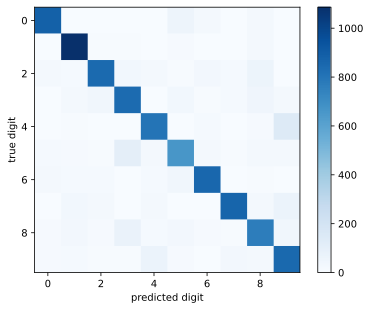

In [7]:
conf = np.zeros((10, 10), dtype=int)
np.add.at(conf, (Y_test, predict(X_test)), 1)          # tally (true, predicted)
off = conf - np.diag(np.diag(conf))                    # errors only
worst = np.dstack(np.unravel_index(
    np.argsort(off, axis=None)[::-1], (10, 10)))[0][:4]
print('most confused true->predicted:',
      ', '.join(f'{t}->{p} ({off[t, p]})' for t, p in worst))
d2l.plt.imshow(conf, cmap='Blues')
d2l.plt.xlabel('predicted digit')
d2l.plt.ylabel('true digit')
d2l.plt.colorbar();

The errors are anything but uniform: the model's worst failures are $4\to9$, $5\to3$, $8\to3$, and $7\to9$ (the reverse confusion $9\to4$ sits just below the printed four). These are largely the digit pairs whose learned *templates*, plotted above, overlap the most: the most-overlapping pair is indeed the top confusion $4/9$, though the correspondence is loose rather than exact, as Exercise 6 lets you check. A $4$ and a $9$ differ mainly in whether the top strokes close into a loop, a fact carried by the *joint* behavior of a handful of neighboring pixels; a model that sees only per-pixel marginals is structurally blind to it. The confusion matrix is the independence assumption's failure map.

Third, the confidence. The class scores determine a genuine posterior: since each score $s_y(\mathbf x)$ is the logarithm of the Bayes-rule numerator $p(\mathbf x\mid y)\,p(y)$, exponentiating and normalizing restores the dropped denominator, so $p(y\mid\mathbf x) = \exp(s_y(\mathbf x))/\sum_{y'}\exp(s_{y'}(\mathbf x))$, a softmax of the scores (Exercise 4 works this out). The model therefore announces a probability along with each predicted digit. A model is **calibrated** if its announced probabilities match empirical
frequencies: among predictions made with confidence $c$, a fraction $c$ should
be correct. We predicted early in this section that multiplying $784$ falsely-independent factors would leave the model badly miscalibrated; the cell below checks, binning the test examples by their maximum posterior and comparing the claimed confidence with the achieved accuracy in each bin, the tabular form of a *reliability diagram*, the standard name for this diagnostic. (The softmax is evaluated in its subtract-the-max stable form from that section.)

In [8]:
s = scores(X_test)
post = np.exp(s - s.max(axis=1, keepdims=True))        # softmax, stably
post /= post.sum(axis=1, keepdims=True)
conf_max = post.max(axis=1)                            # claimed confidence
print(f'mean claimed confidence = {conf_max.mean():.3f},   '
      f'actual accuracy = {correct.mean():.3f}')
for a, b in zip([0.0, 0.9, 0.99, 0.999], [0.9, 0.99, 0.999, 1.0]):
    m = (conf_max > a) & (conf_max <= b)
    print(f'confidence in ({a}, {b}]: {m.sum():5d} examples,  '
          f'claimed {conf_max[m].mean():.4f},  achieved {correct[m].mean():.4f}')

mean claimed confidence = 0.986,   actual accuracy = 0.843
confidence in (0.0, 0.9]:   447 examples,  claimed 0.7229,  achieved 0.3736
confidence in (0.9, 0.99]:   455 examples,  claimed 0.9606,  achieved 0.4747
confidence in (0.99, 0.999]:   406 examples,  claimed 0.9960,  achieved 0.5640
confidence in (0.999, 1.0]:  8692 examples,  claimed 1.0000,  achieved 0.8991


On average the model claims $98.6\%$ confidence while delivering $84.3\%$ accuracy, and the miscalibration is worst where the claims are strongest: $87\%$ of all test examples land in the top bin, where the model asserts essentially $100\%$ certainty yet is right only $89.9\%$ of the time, and every other bin overstates itself too, with examples announced at $72\%$ confidence being correct barely $37\%$ of the time. (The *ordering* still carries signal, since accuracy does rise with confidence bin, but the probabilities themselves are grossly inflated.) This is exactly what the log-space picture predicts. Each of the $784$ pixels contributes its log-likelihood ratio to the score *as if* it were independent evidence, so correlated pixels get counted many times over and the score gaps between classes grow far beyond what the evidence supports: the median gap between the best and second-best class score on the test set is about $30$ nats (natural-log units; that section makes the unit precise), and since $e^{-30}\approx 10^{-13}$ that already pushes the softmax to $0$ or $1$; gaps of hundreds of nats occur only between the best and *worst* classes. The same failure extends well past naive Bayes: modern neural classifiers trained to low loss are overconfident in the same direction, though to a smaller degree [@Guo.Pleiss.Sun.Weinberger.2017], which is why the reliability check you just ran, confidence binned against accuracy, is a standard diagnostic for any classifier whose probabilities you intend to consume.

## Summary

* Bayes' rule recasts classification generatively: $p(y\mid\mathbf{x}) \propto p(\mathbf{x}\mid y)\,p(y)$, predicting the label that maximizes the numerator.
* As a **generative** model it estimates $p(\mathbf{x}\mid y)\,p(y)$, the mirror image of a **discriminative** model like softmax regression, which estimates $p(y\mid\mathbf{x})$ directly. Sample-efficiency and asymptotic-error comparisons depend on the model families and which assumptions match the data.
* The **naive** conditional-independence assumption $p(\mathbf{x}\mid y)=\prod_i p(x_i\mid y)$ replaces $\mathcal{O}(2^d)$ parameters with $\mathcal{O}(d)$, and the classifier needs only the $\mathrm{argmax}$, not the probabilities, to be right.
* Working in log space avoids the underflow of multiplying hundreds of probabilities. Bernoulli and multinomial naive Bayes have scores affine in their chosen features and therefore linear decision boundaries; Gaussian naive Bayes with class-dependent variances generally has quadratic boundaries.
* Training is maximum likelihood by counting: class priors and per-feature frequencies. Laplace smoothing, $(n_{iy}+1)/(n_y+2)$ for a binary feature, is the posterior mean under a uniform prior (that section) and keeps every log-probability finite.
* On MNIST it learns ten averaged digit templates and classifies respectably, but its independence assumption caps accuracy. It shines where features are closer to independent, the canonical case being bag-of-words text classification.
* The $84.27\%$ carries a bootstrap error bar of about $\pm 0.7$ points; the confusion matrix localizes the failures in template-overlapping pairs like $4/9$ and $5/3$; and the model is severely **miscalibrated**, claiming $98.6\%$ mean confidence while delivering $84.3\%$ accuracy, because falsely independent factors double-count correlated evidence. Bin confidence against accuracy (a reliability diagram) before trusting any classifier's probabilities.

## Exercises
1. Consider the dataset $\{(0,0),(0,1),(1,0),(1,1)\}$ with labels given by the XOR of the two coordinates, $\{0,1,1,0\}$. Compute the naive Bayes estimates $p(y)$ and $p(x_i\mid y)$. Does the classifier separate the points? If not, which assumption is violated?
2. Suppose we omitted Laplace smoothing and, at test time, an example contained a feature value never observed for some class in training. What would the model's log-score for that class be, and why?
3. The naive Bayes classifier is a special case of a Bayesian network, in which dependencies among random variables are encoded by a graph (see @Koller.Friedman.2009). Explain why adding an explicit edge between the two inputs of the XOR model would let it classify the points correctly.
4. The discussion after the equation showed that each class score of the binary model is affine, $s_y(\mathbf{x}) = \mathbf{w}_y\cdot\mathbf{x} + b_y$. Derive the exact posterior by normalizing: show that $p(y\mid\mathbf{x}) = \exp(s_y(\mathbf{x}))\,/\sum_{y'} \exp(s_{y'}(\mathbf{x}))$, and recognize the softmax. Conclude that naive Bayes produces posteriors of exactly the functional form that softmax regression (that section) fits directly; the two classifiers differ only in how the weights $\mathbf{w}_y, b_y$ are set. (With two classes, you recover logistic regression.)
5. Generalize the smoothing in the training cell to a pseudocount $\alpha$, estimating $p(x_i{=}1\mid y)$ as $(n_{iy}+\alpha)/(n_y+2\alpha)$, and report the MNIST test accuracy for $\alpha\in\{0,1,10\}$. Explain what you observe at $\alpha=0$: beyond the $-\infty$ log-probabilities of exercise 2, what does the scoring code compute when a pixel with $\hat p(x_i{=}1\mid y)=0$ is *off* in a test image? (Recall that $0\cdot(-\infty)$ is NaN in floating point.)
6. Check the template-overlap explanation of the confusion matrix: flatten the ten smoothed templates in $P_{xy}$ into vectors and compute the cosine similarity of every pair (one line with NumPy). Which pairs overlap most, and how well do they match the top confusions? You should find that $(4,9)$ is the most similar pair, at cosine similarity about $0.92$, matching the top confusion, but that the second most similar pair, $(5,8)$ at about $0.91$, is *not* among the top four confusions: the correspondence between template overlap and confusion is real but loose.

[Discussions](https://d2l.discourse.group/t/1101)